# Naive Bayes Case Study — Titanic Survival

Predict whether a passenger survived using Gaussian Naive Bayes.


## 1) Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")


## 2) Load + explore

Load Titanic from sklearn, then rename columns.


In [ ]:
# Titanic dataset from sklearn (OpenML)
titanic = fetch_openml("titanic", version=1, as_frame=True, parser="auto")
df = titanic.frame.copy()

# normalize names for the rest of the notebook
df = df.rename(columns={
    "pclass": "Pclass",
    "survived": "Survived",
    "name": "Name",
    "sex": "Sex",
    "age": "Age",
    "sibsp": "SibSp",
    "parch": "Parch",
    "ticket": "Ticket",
    "fare": "Fare",
    "cabin": "Cabin",
    "embarked": "Embarked",
})
df["Survived"] = df["Survived"].astype(int)

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nDtypes:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

df.head()


Shape: (1309, 14)

Columns: ['Pclass', 'Survived', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'boat', 'body', 'home.dest']

Dtypes:
Pclass          int64
Survived        int64
Name              str
Sex          category
Age           float64
SibSp           int64
Parch           int64
Ticket            str
Fare          float64
Cabin             str
Embarked     category
boat              str
body          float64
home.dest         str
dtype: object

Missing values:
Pclass          0
Survived        0
Name            0
Sex             0
Age           263
SibSp           0
Parch           0
Ticket          0
Fare            1
Cabin        1014
Embarked        2
boat          823
body         1188
home.dest     564
dtype: int64


,Pclass,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## 3) Quick EDA


Survived
0    809
1    500
Name: count, dtype: int64

Survival rate (%):
Survived
0    61.802903
1    38.197097
Name: proportion, dtype: float64


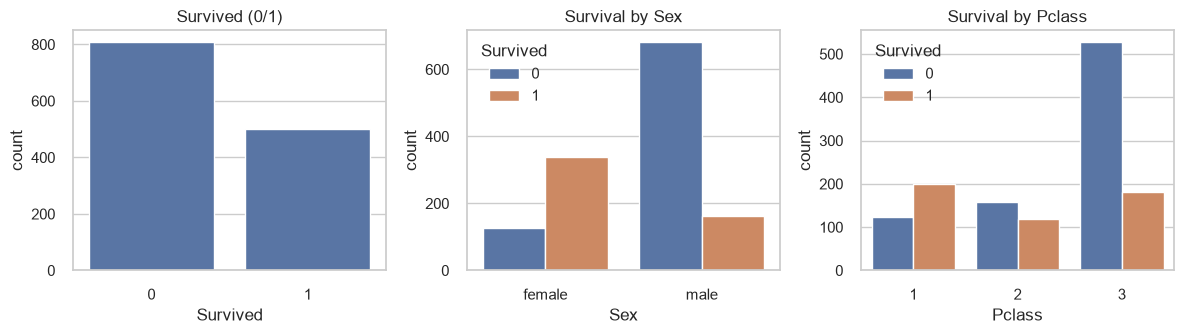


Summary:
            Pclass     Survived          Age        SibSp        Parch  \
count  1309.000000  1309.000000  1046.000000  1309.000000  1309.000000   
mean      2.294882     0.381971    29.881135     0.498854     0.385027   
std       0.837836     0.486055    14.413500     1.041658     0.865560   
min       1.000000     0.000000     0.166700     0.000000     0.000000   
25%       2.000000     0.000000    21.000000     0.000000     0.000000   
50%       3.000000     0.000000    28.000000     0.000000     0.000000   
75%       3.000000     1.000000    39.000000     1.000000     0.000000   
max       3.000000     1.000000    80.000000     8.000000     9.000000   

              Fare        body  
count  1308.000000  121.000000  
mean     33.295479  160.809917  
std      51.758668   97.696922  
min       0.000000    1.000000  
25%       7.895800   72.000000  
50%      14.454200  155.000000  
75%      31.275000  256.000000  
max     512.329200  328.000000  


In [3]:
print(df["Survived"].value_counts())
print("\nSurvival rate (%):")
print(df["Survived"].value_counts(normalize=True) * 100)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

sns.countplot(x="Survived", data=df, ax=axes[0])
axes[0].set_title("Survived (0/1)")

sns.countplot(x="Sex", hue="Survived", data=df, ax=axes[1])
axes[1].set_title("Survival by Sex")

sns.countplot(x="Pclass", hue="Survived", data=df, ax=axes[2])
axes[2].set_title("Survival by Pclass")

plt.tight_layout()
plt.show()

print("\nSummary:")
print(df.describe())


## 4) Select features

Drop noise / leakage cols. Missing values + encoding happen later inside the Pipeline (so no data leakage from fill stats).


In [4]:
drop_cols = [c for c in ["Name", "Ticket", "Cabin", "boat", "body", "home.dest"] if c in df.columns]
data = df.drop(columns=drop_cols).copy()

# keep categoricals as strings for OneHotEncoder
data["Sex"] = data["Sex"].astype(str)
data["Embarked"] = data["Embarked"].astype(str)

print("Columns kept:", list(data.columns))
print("\nMissing (will be handled in Pipeline):")
print(data.isnull().sum())
data.head()


Columns kept: ['Pclass', 'Survived', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Missing (will be handled in Pipeline):
Pclass        0
Survived      0
Sex           0
Age         263
SibSp         0
Parch         0
Fare          1
Embarked      2
dtype: int64


,Pclass,Survived,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,1,female,29.0000,0,0,211.3375,S
1,1,1,male,0.9167,1,2,151.5500,S
2,1,0,female,2.0000,1,2,151.5500,S
3,1,0,male,30.0000,1,2,151.5500,S
4,1,0,female,25.0000,1,2,151.5500,S


## 5) Train / test split


In [5]:
X = data.drop("Survived", axis=1)
y = data["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Features:", list(X.columns))


Train: (1047, 7) Test: (262, 7)
Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


## 6) Pipeline + GaussianNB

One Pipeline does:
1. impute numerics (median) / categoricals (most frequent)
2. one-hot encode `Sex`, `Embarked`
3. GaussianNB

Then `GridSearchCV` tunes `var_smoothing` with stratified CV.


In [6]:
num_cols = ["Pclass", "Age", "SibSp", "Parch", "Fare"]
cat_cols = ["Sex", "Embarked"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ]
)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", GaussianNB()),
])

param_grid = {
    "model__var_smoothing": np.logspace(-11, -7, 5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best CV accuracy:", round(grid.best_score_, 4))
print("Best params:", grid.best_params_)
print("\nPipeline steps:", list(grid.best_estimator_.named_steps.keys()))

best_model = grid.best_estimator_


Best CV accuracy: 0.7756
Best params: {'model__var_smoothing': np.float64(1e-11)}

Pipeline steps: ['preprocess', 'model']


## 7) Evaluation


Test accuracy: 0.7939

Classification report:
              precision    recall  f1-score   support

    Died (0)       0.85      0.81      0.83       162
Survived (1)       0.72      0.76      0.74       100

    accuracy                           0.79       262
   macro avg       0.78      0.79      0.78       262
weighted avg       0.80      0.79      0.79       262



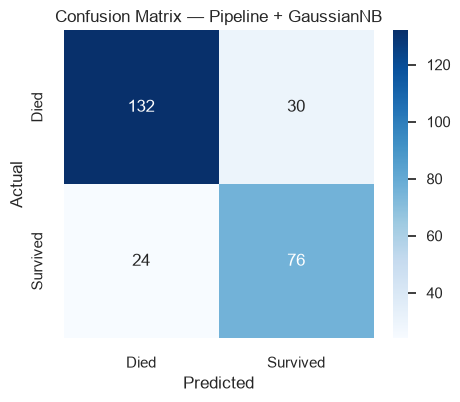

In [7]:
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Test accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Died (0)", "Survived (1)"]))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Died", "Survived"],
            yticklabels=["Died", "Survived"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Pipeline + GaussianNB")
plt.show()


## 8) Short analysis

- Data from `fetch_openml("titanic")` (~1309 rows). Sex / Pclass still matter a lot in EDA.
- Preprocessing is inside a **Pipeline** (impute + one-hot + GaussianNB), so fill/encode stats are fit only on training folds during CV — cleaner than doing it by hand before the split.
- `GridSearchCV` picks `var_smoothing`. Check the printed CV / test scores after re-run.
- NB independence assumption is still a stretch, but this is a good baseline setup. Next: FamilySize / Title features, or another model.


## 9) Optional: predict one passenger


In [8]:
# raw values — Pipeline handles impute + encode
sample = pd.DataFrame([{
    "Pclass": 3,
    "Sex": "male",
    "Age": 22,
    "SibSp": 1,
    "Parch": 0,
    "Fare": 7.25,
    "Embarked": "S",
}])

pred = best_model.predict(sample)[0]
proba = best_model.predict_proba(sample)[0]
print(sample)
print("Prediction:", "Survived" if pred == 1 else "Died")
print("P(died), P(survived):", proba.round(3))


   Pclass   Sex  Age  SibSp  Parch  Fare Embarked
0       3  male   22      1      0  7.25        S
Prediction: Died
P(died), P(survived): [0.989 0.011]
